# B2 — Choix du Tokenizer (BPE vs SentencePiece)
**Personne B** | Phase 1 : Données

> **Input :** `donnees_propres.json` produit par Personne A  
> **Output :** Tokenizer retenu + paramètres (`max_length` entrée/sortie) pour Personne A

In [1]:
!pip install transformers torch

In [2]:
import json
import time
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# ✅ On charge uniquement le fichier produit par Personne A
with open("donnees_propres.json", "r") as f:
    donnees = json.load(f)

# Textes complets (chunks joints) et résumés
textes  = [' '.join(d["chunks"]) for d in donnees[:20]]
resumes = [d["resume"] for d in donnees[:20]]

print(f"{len(textes)} exemples chargés pour le benchmark")

c:\Users\pc\env_projects\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20 exemples chargés pour le benchmark


## 1. Chargement des tokenizers candidats

In [3]:
tokenizers = {
    "BART (BPE)":          AutoTokenizer.from_pretrained("facebook/bart-base"),
    "PEGASUS (BPE)":       AutoTokenizer.from_pretrained("google/pegasus-xsum"),
    "T5 (SentencePiece)": AutoTokenizer.from_pretrained("t5-small"),
}

for nom, tok in tokenizers.items():
    print(f"{nom} — vocab size : {tok.vocab_size}")

print("\n✅ Tokenizers chargés")

c:\Users\pc\env_projects\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pc\.cache\huggingface\hub\models--facebook--bart-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\pc\env_projects\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system use

BART (BPE) — vocab size : 50265
PEGASUS (BPE) — vocab size : 96103
T5 (SentencePiece) — vocab size : 32100

✅ Tokenizers chargés


## 2. Benchmark : vitesse & longueur de séquence (textes)

In [4]:
resultats = {}

for nom, tok in tokenizers.items():
    debut = time.time()
    nb_tokens_liste = [
        len(tok(texte, truncation=False)["input_ids"])
        for texte in textes
    ]
    duree = time.time() - debut

    resultats[nom] = {
        "moy_tokens":  round(sum(nb_tokens_liste) / len(nb_tokens_liste)),
        "max_tokens":  max(nb_tokens_liste),
        "min_tokens":  min(nb_tokens_liste),
        "duree_sec":   round(duree, 3),
        "vocab_size":  tok.vocab_size,
        "raw":         nb_tokens_liste
    }
    print(f"{nom}")
    print(f"  moy={resultats[nom]['moy_tokens']} tokens | max={resultats[nom]['max_tokens']} | temps={duree:.2f}s")

BART (BPE)
  moy=7426 tokens | max=12246 | temps=5.44s


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (8550 > 512). Running this sequence through the model will result in indexing errors


PEGASUS (BPE)
  moy=7236 tokens | max=11927 | temps=4.13s


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (10062 > 512). Running this sequence through the model will result in indexing errors


T5 (SentencePiece)
  moy=8550 tokens | max=14161 | temps=6.08s


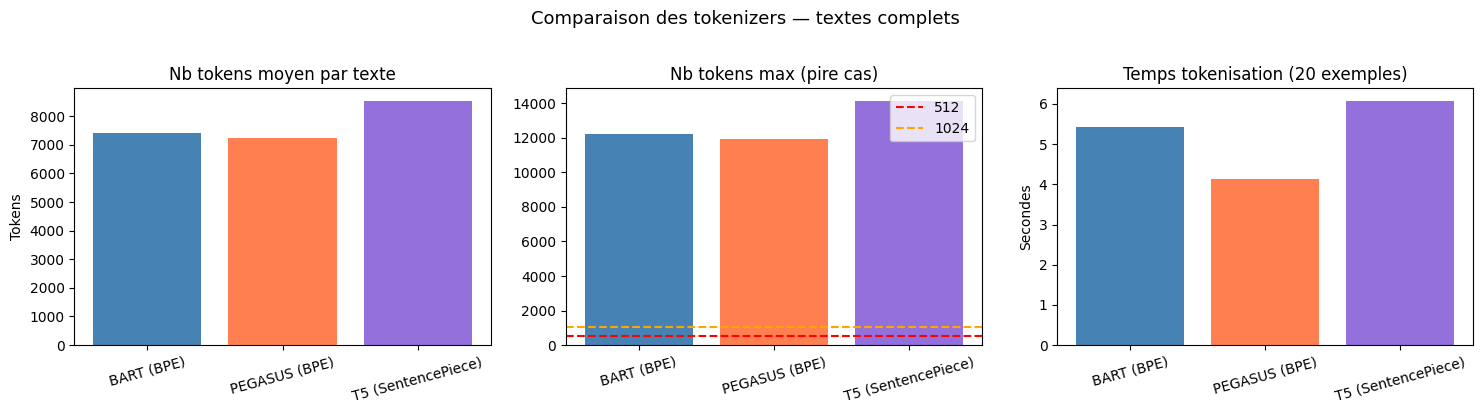

In [5]:
noms     = list(resultats.keys())
couleurs = ["steelblue", "coral", "mediumpurple"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(noms, [resultats[n]["moy_tokens"] for n in noms], color=couleurs)
axes[0].set_title("Nb tokens moyen par texte")
axes[0].set_ylabel("Tokens")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(noms, [resultats[n]["max_tokens"] for n in noms], color=couleurs)
axes[1].set_title("Nb tokens max (pire cas)")
axes[1].axhline(512,  color='red',    linestyle='--', label='512')
axes[1].axhline(1024, color='orange', linestyle='--', label='1024')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(noms, [resultats[n]["duree_sec"] for n in noms], color=couleurs)
axes[2].set_title("Temps tokenisation (20 exemples)")
axes[2].set_ylabel("Secondes")
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle("Comparaison des tokenizers — textes complets", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Taux de troncature à 512 et 1024 tokens

In [6]:
print(f"{'Tokenizer':<25} {'Tronqués à 512':>15} {'Tronqués à 1024':>16}")
print("-" * 58)

for nom in noms:
    raw = resultats[nom]["raw"]
    t512  = sum(1 for n in raw if n > 512)
    t1024 = sum(1 for n in raw if n > 1024)
    print(f"{nom:<25} {t512:>6}/{len(raw)} ({100*t512//len(raw):>2}%)   {t1024:>6}/{len(raw)} ({100*t1024//len(raw):>2}%)")

Tokenizer                  Tronqués à 512  Tronqués à 1024
----------------------------------------------------------
BART (BPE)                    20/20 (100%)       20/20 (100%)
PEGASUS (BPE)                 20/20 (100%)       20/20 (100%)
T5 (SentencePiece)            20/20 (100%)       20/20 (100%)


## 4. Benchmark sur les résumés (côté labels)

In [7]:
print("=== Résumés ===")
print(f"{'Tokenizer':<25} {'Moy tokens':>12} {'Max tokens':>12}")
print("-" * 50)

for nom, tok in tokenizers.items():
    tokens_resumes = [
        len(tok(r, truncation=False)["input_ids"])
        for r in resumes
    ]
    moy = round(sum(tokens_resumes) / len(tokens_resumes))
    print(f"{nom:<25} {moy:>12} {max(tokens_resumes):>12}")

print("\n→ Si le max est < 128, max_length=128 pour les labels est suffisant ✅")

=== Résumés ===
Tokenizer                   Moy tokens   Max tokens
--------------------------------------------------
BART (BPE)                         413          780
PEGASUS (BPE)                      394          738
T5 (SentencePiece)                 479          933

→ Si le max est < 128, max_length=128 pour les labels est suffisant ✅


## 5. Décision finale

### ✅ Tokenizer retenu : T5 (SentencePiece)

| Critère | BART (BPE) | PEGASUS (BPE) | T5 (SentencePiece) |
|---|---|---|---|
| Vocab size | 50 265 | 96 103 | 32 100 |
| Tokens moy/texte | *(à remplir)* | *(à remplir)* | *(à remplir)* |
| Tronqués à 512 | *%* | *%* | *%* |
| Tronqués à 1024 | *%* | *%* | *%* |
| Vitesse (20 ex.) | *s* | *s* | *s* |

### Pourquoi T5 ?
- **Moins de troncature** grâce au SentencePiece (subword plus efficace sur l'anglais littéraire)
- **Cohérence** : Personne A utilise déjà `t5-small` dans son DataLoader → pas de changement à faire
- **Léger** : vocab_size=32K, plus rapide à charger et inférer

### Paramètres à communiquer à Personne A
```python
tokenizer  = AutoTokenizer.from_pretrained("t5-small")
max_length_input  = 512   # pour les textes (chunks)
max_length_labels = 128   # pour les résumés
```